# Longitudinal phage dynamics

In [1]:
### Load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

plt.rcParams.update({'font.size': 14})

In [2]:
### Load samplesheet
# 1. > 6 month time frame
# 2. At least 3 timepoints
# 3. All sputum samples
# 4. 10E+08 bp read depth per sample

samplesheet = (
    pl.read_csv('cf_longitudinal_samplesheet.csv')
        .with_columns([
            pl.when(pl.col('condition').is_in(['no exacerbation', 'normal'])).then(pl.lit('stable'))
                .when(pl.col('condition').is_in(['exacerbation', 'ex', 'pe'])).then(pl.lit('exacerbation'))
                .otherwise(pl.lit('Unknown'))
                .alias('clinical_status')
        ])
)

read_depth = (
    pl.read_csv('../figure_5/cf_metag_read_depth.txt.gz', separator='\t', has_header=False)
        .rename({'column_1': 'sample_id', 'column_2': 'num_bp'})
)

samplesheet_w_depth = (
    samplesheet
        .join(read_depth, left_on='sample', right_on='sample_id', how='left')
)

In [3]:
### identify longitudinal subjects meeting criteria
long_groups = set(
    samplesheet_w_depth
        .filter(
            (
                (pl.col('num_bp') >= 1e8) &
                (pl.col('sample_type') == 'sputum') &
                (pl.col('timepoint').str.contains(r'20\d{2}-\d{2}-\d{2}'))
            ) |
            (pl.col('bioproject').str.contains('lipuma'))
        )
        .with_columns(
            pl.col('timepoint').str.to_date('%Y-%m-%d').alias('timepoint')
        )
        .unique(['coassembly_group', 'timepoint'])
        .group_by(['coassembly_group'])
        .agg([
            pl.col('timepoint').min().alias('min_timepoint'),
            pl.col('timepoint').max().alias('max_timepoint'),
            pl.len().alias('num_timepoints')
        ])
        .with_columns([
            (pl.col('max_timepoint') - pl.col('min_timepoint')).dt.total_days().alias('time_frame_days')
        ])
        .filter(
            (
                (pl.col('time_frame_days') >= 180) &
                (pl.col('num_timepoints') >= 3)
            ) |
            (pl.col('coassembly_group').is_in(['L06', 'L12', 'L13']))
        )
        ['coassembly_group']
)
len(long_groups)

17

In [4]:
### Load activity data and filter to longitudinal groups
activity_df = pl.read_csv('../figure_5/cf_metag_hybrid_activity_data.tsv', separator='\t')
sylph_tax_df = pl.read_csv('../figure_5/cf_metag_sylph_tax_results.tsv.gz', separator='\t')

### Merge sylph data with samplesheet
merged = (
    activity_df
        .join(samplesheet_w_depth[['sample', 'bioproject', 'coassembly_group', 'clinical_status', 'timepoint', 'sample_type', 'num_bp']], left_on='sample_id', right_on='sample')
        .filter(
            (pl.col('coassembly_group').is_in(long_groups)) &
            (
                (
                    (pl.col('num_bp') >= 1e8) &
                    (pl.col('sample_type') == 'sputum') &
                    (pl.col('timepoint').str.contains(r'20\d{2}-\d{2}-\d{2}'))
                ) |
                (
                    (pl.col('bioproject').str.contains('lipuma'))
                )
            )
        )
        .with_columns(
            pl.col('timepoint').str.to_date('%Y-%m-%d').alias('timepoint')
        )
)

In [5]:
### Display number of individuals per bioproject
merged.unique('coassembly_group').group_by(['bioproject']).len()

bioproject,len
str,u32
"""PRJEB32062""",4
"""lipuma_aim2""",3
"""PRJNA516870""",10


In [6]:
### Display number of samples per bioproject
merged.unique('sample_id').group_by(['bioproject']).len()

bioproject,len
str,u32
"""lipuma_aim2""",34
"""PRJEB32062""",19
"""PRJNA516870""",36


In [7]:
### Identify max activity per virus species per subject
tier_rank_expr = (
    pl.when(pl.col('hybrid_confidence_tier') == 'High').then(pl.lit(3))
      .when(pl.col('hybrid_confidence_tier') == 'Medium').then(pl.lit(2))
      .when(pl.col('hybrid_confidence_tier') == 'Low').then(pl.lit(1))
      .otherwise(pl.lit(0))
 )

tier_label_expr = (
    pl.when(pl.col('top_confidence_rank') == 3).then(pl.lit('High'))
      .when(pl.col('top_confidence_rank') == 2).then(pl.lit('Medium'))
      .when(pl.col('top_confidence_rank') == 1).then(pl.lit('Low'))
      .otherwise(pl.lit('No Prediction'))
 )

top_tier = (
    merged
        .select(['species_cluster_id', 'coassembly_group', 'sample_id', 'hybrid_confidence_tier'])
        .drop_nulls(['species_cluster_id', 'coassembly_group', 'sample_id','hybrid_confidence_tier'])
        .with_columns([
            tier_rank_expr.alias('tier_rank'),
        ])
        .group_by(['species_cluster_id', 'coassembly_group'])
        .agg([
            pl.col('tier_rank').max().alias('top_confidence_rank'),
        ])
        .with_columns([
            tier_label_expr.alias('top_confidence_tier'),
        ])
        .with_columns([pl.col('top_confidence_tier').str.replace('No Prediction', 'No Filter')])
        [['species_cluster_id', 'coassembly_group', 'top_confidence_tier']]
)

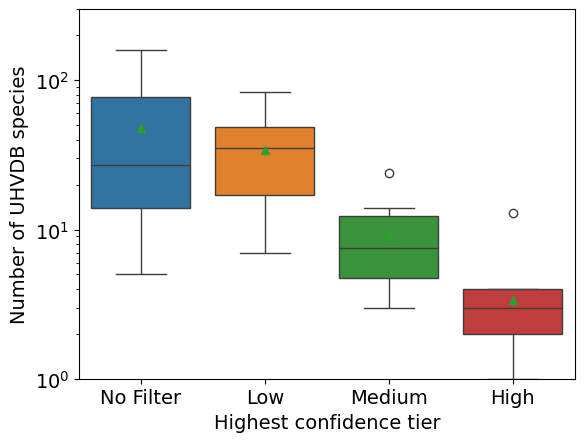

In [8]:
### Count number of viruses per coassembly group by activity level
virus_richness_by_group= (
    merged
        .join(top_tier, on=['coassembly_group', 'species_cluster_id'], how='left')
        .group_by(['coassembly_group', 'top_confidence_tier'])
        .agg(pl.col('species_cluster_id').n_unique().alias('virus_count'))
        .sort(['coassembly_group', 'top_confidence_tier'])
)

sns.boxplot(
    virus_richness_by_group,
    x='top_confidence_tier',
    y='virus_count',
    order=['No Filter', 'Low', 'Medium', 'High'],
    showmeans=True,
    showfliers=True,
    hue='top_confidence_tier',
    hue_order=['No Filter', 'Low', 'Medium', 'High']
)
plt.ylabel('Number of UHVDB species')
plt.xlabel('Highest confidence tier')
plt.yscale('log')
plt.ylim(1,300)
plt.show()

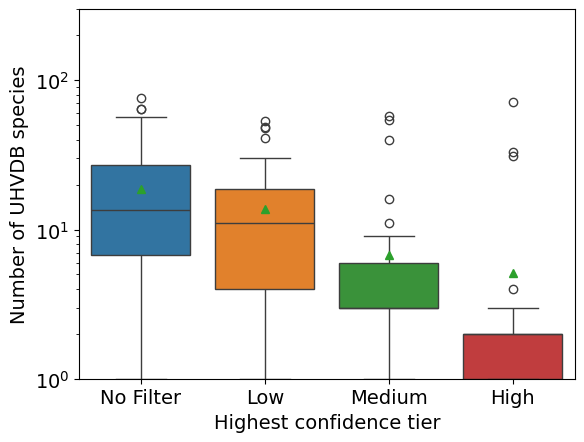

In [9]:
### Count number of viruses per sample by activity level
virus_richness_by_sample = (
    merged
        .join(top_tier, on=['coassembly_group', 'species_cluster_id'], how='left')
        .group_by(['coassembly_group', 'top_confidence_tier', 'timepoint'])
        .len()
        .sort(['coassembly_group', 'top_confidence_tier'])
)

sns.boxplot(
    virus_richness_by_sample,
    x='top_confidence_tier',
    y='len',
    order=['No Filter', 'Low', 'Medium', 'High'],
    showmeans=True,
    showfliers=True,
    hue='top_confidence_tier',
    hue_order=['No Filter', 'Low', 'Medium', 'High']
)
plt.ylabel('Number of UHVDB species')
plt.xlabel('Highest confidence tier')
plt.yscale('log')
plt.ylim(1,300)
plt.show()

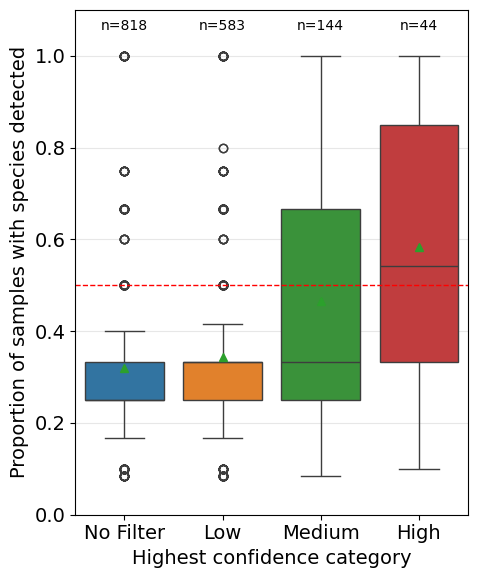

In [10]:
### Calculate virus persistence by activity level
# Get total number of samples per coassembly group
samples_per_group = (
    merged
        .select(['coassembly_group', 'sample_id'])
        .unique()
        .group_by('coassembly_group')
        .agg(pl.col('sample_id').n_unique().alias('total_samples'))
)

# Calculate persistence for each virus
persistence = (
    merged
        .group_by([
            'coassembly_group', 'species_cluster_id', 'most_common_ictv_class', 'most_common_ictv_family', 'most_common_family_cluster_id', 'most_common_host_taxonomy',
            'med_temperate_score', 'num_genomovars_in_species', 'count_integration_related', 'count_integrated'
        ])
        .agg([
            pl.col('sample_id').n_unique().alias('samples_detected'),
        ])
        .join(samples_per_group, on='coassembly_group')
        .with_columns([
            (pl.col('samples_detected') / pl.col('total_samples')).alias('persistence'),
            pl.col('most_common_host_taxonomy').str.split(';f__').list[-1].str.split(';g__').list[0].alias('host_family')
        ])
        .join(top_tier, on=['coassembly_group', 'species_cluster_id'], how='left')
)

# Visualize persistence by activity level
plt.figure(figsize=(5, 6))
ax = sns.boxplot(
    data=persistence,
    x='top_confidence_tier',
    y='persistence',
    order=['No Filter', 'Low', 'Medium', 'High'],
    showmeans=True,
    hue='top_confidence_tier',
)

# Add counts above each boxplot
activity_order = ['No Filter', 'Low', 'Medium', 'High']
for i, activity in enumerate(activity_order):
    count = persistence.filter(pl.col('top_confidence_tier') == activity).unique(['species_cluster_id', 'coassembly_group']).height
    ax.text(i, 1.05, f'n={count}', ha='center', va='bottom', fontsize=10)

plt.xlabel('Highest confidence category')
plt.ylabel('Proportion of samples with species detected')
plt.ylim(0,1.1)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
# add horizontal line at 0.5
plt.axhline(0.5, color='red', linestyle='--', linewidth=1)
plt.show()

In [11]:
201/305

0.659016393442623

In [12]:
persistence.filter(pl.col('persistence') >= 0.5).filter(pl.col('top_confidence_tier').is_in(['Low', 'Medium', 'High'])).unique(['coassembly_group', 'species_cluster_id']).height

201

In [13]:
bac_persistence = (
    sylph_tax_df
        .filter(pl.col('clade_name').str.contains('Bacteria'))
        .filter(pl.col('clade_name').str.contains('s__'))
        .filter(~pl.col('clade_name').str.contains('t__'))
        .join(samplesheet_w_depth[['sample', 'bioproject', 'coassembly_group', 'clinical_status', 'timepoint', 'sample_type', 'num_bp']], left_on='sample_id', right_on='sample')
        .filter(
            (pl.col('coassembly_group').is_in(long_groups)) &
            (
                (
                    (pl.col('num_bp') >= 1e8) &
                    (pl.col('sample_type') == 'sputum') &
                    (pl.col('timepoint').str.contains(r'20\d{2}-\d{2}-\d{2}'))
                ) |
                (
                    (pl.col('bioproject').str.contains('lipuma'))
                )
            )
        )
        .with_columns(
            pl.col('timepoint').str.to_date('%Y-%m-%d').alias('timepoint')
        )
        .group_by([
            'coassembly_group', 'clade_name'
        ])
        .agg([
            pl.col('sample_id').n_unique().alias('samples_detected'),
        ])
        .join(samples_per_group, on='coassembly_group')
        .with_columns([
            (pl.col('samples_detected') / pl.col('total_samples')).alias('persistence'),
            pl.lit('Bacteria').alias('top_confidence_tier')
        ])
)

In [14]:
471/1220

0.3860655737704918

In [15]:
bac_persistence.filter(pl.col('persistence') >= 0.5).unique(['coassembly_group', 'clade_name']).height

471

/tmp/ipykernel_44168/2705283359.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


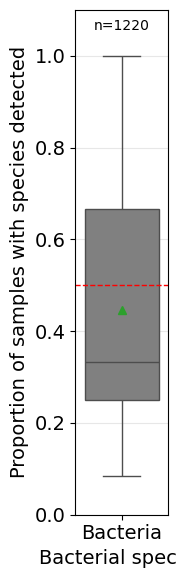

In [16]:
### Bacterial persistence
plt.figure(figsize=(2, 6))
ax = sns.boxplot(
    data=bac_persistence,
    x='top_confidence_tier',
    y='persistence',
    showmeans=True,
    palette='grey'
)

# Add counts above each boxplot
activity_order = ['Bacteria']
for i, activity in enumerate(activity_order):
    count = bac_persistence.filter(pl.col('top_confidence_tier') == activity).unique(['clade_name', 'coassembly_group']).height
    ax.text(i, 1.05, f'n={count}', ha='center', va='bottom', fontsize=10)

plt.xlabel('Bacterial species')
plt.ylabel('Proportion of samples with species detected')
plt.ylim(0,1.1)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
# add horizontal line at 0.5
plt.axhline(0.5, color='red', linestyle='--', linewidth=1)
plt.show()

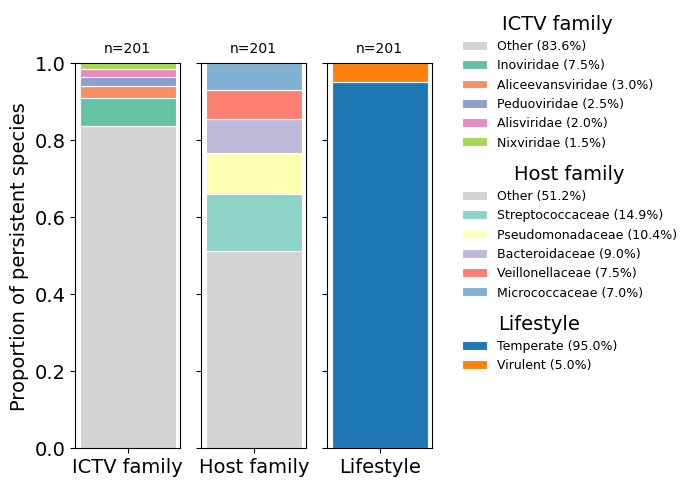

In [30]:
### Combined plot: ICTV family, host family, and temperate evidence
def top_n_with_other(df, col_name, top_n=10):
    base = (
        df
            .with_columns(
                pl.when(
                    pl.col(col_name).is_null() |
                    (pl.col(col_name).str.strip_chars() == '')
                )
                .then(pl.lit('Unknown'))
                .otherwise(pl.col(col_name))
                .alias(col_name)
            )
            .group_by(col_name)
            .agg(pl.len().alias('n_viruses'))
            .sort('n_viruses', descending=True)
    )
    top_vals = base.head(top_n)[col_name].to_list()
    out = (
        base
            .with_columns(
                pl.when((pl.col(col_name).is_in(top_vals)) & (pl.col(col_name) != 'Unclassified'))
                .then(pl.col(col_name))
                .otherwise(pl.lit('Other'))
                .alias('group')
            )
            .group_by('group')
            .agg(pl.sum('n_viruses').alias('n_viruses'))
            .with_columns((pl.col('n_viruses') / pl.col('n_viruses').sum()).alias('proportion'))
            .sort('proportion', descending=True)
    )
    return out.to_dicts()

def stacked_bar(ax, plot_data, bar_label, special_colors=None, palette_name='tab10'):
    if special_colors is None:
        special_colors = {}

    non_special = [
        d['group'] for d in plot_data
        if d['group'] not in {'Other', 'Unclassified', 'No temperate evidence'}
    ]
    palette = sns.color_palette(palette_name, n_colors=max(len(non_special), 1))
    color_map = {name: palette[i] for i, name in enumerate(non_special)}
    color_map.update({
        'Other': 'lightgrey',
        'Unclassified': 'dimgray',
        'No temperate evidence': 'lightgrey'
    })
    color_map.update(special_colors)

    bottom = 0.0
    for row in plot_data:
        group = row['group']
        prop = row['proportion']
        ax.bar(
            bar_label,
            prop,
            bottom=bottom,
            color=color_map.get(group, 'lightgrey'),
            edgecolor='white',
            linewidth=0.8,
            label=f"{group} ({prop:.1%})"
        )
        bottom += prop

    # Add total count at the top of each stacked bar
    total_n = int(sum(row.get('n_viruses', 0) for row in plot_data))
    if total_n > 0:
        ax.text(0, 1.02, f'n={total_n}', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=10)

    ax.set_ylim(0, 1)
    ax.set_xlabel('')

# Base persistent set
persistent_base = (
    persistence
        .filter(pl.col('persistence') >= 0.5)
        .filter(pl.col('top_confidence_tier').is_in(['Low', 'Medium', 'High']))
)

# 1) ICTV family (top 5 + Other)
family_plot_data = top_n_with_other(persistent_base, 'most_common_ictv_family', top_n=6)

# 2) Host family (top 10 + Other)
host_plot_data = top_n_with_other(persistent_base, 'host_family', top_n=6)

# 3) Temperate evidence (fixed order/colors)
temperate_order = [
    'Temperate',
    'Virulent'
 ]
temperate_data = (
    persistent_base
        .with_columns(
            (pl.col('count_integration_related') / pl.col('num_genomovars_in_species')).alias('integration_related_prop'),
            (pl.col('count_integrated') / pl.col('num_genomovars_in_species')).alias('integrated_prop')
        )
        .with_columns([
            pl.when(pl.col('integrated_prop') > 0.5).then(pl.lit('Temperate'))
                .when(pl.col('med_temperate_score') > 0.5).then(pl.lit('Temperate'))
                .when(pl.col('integration_related_prop') > 0.5).then(pl.lit('Temperate'))
                .otherwise(pl.lit('Virulent')).alias('group')
        ])
        .group_by('group')
        .agg(pl.len().alias('n_viruses'))
        .with_columns(
            pl.col('group').replace_strict(
                temperate_order,
                list(range(len(temperate_order))),
                default=len(temperate_order)
            ).alias('order_idx')
        )
        .sort('order_idx')
        .with_columns((pl.col('n_viruses') / pl.col('n_viruses').sum()).alias('proportion'))
        .select(['group', 'n_viruses', 'proportion'])
        .to_dicts()
 )

fig, axes = plt.subplots(1, 3, figsize=(6, 5), sharey=True)

stacked_bar(axes[0], family_plot_data, 'ICTV family', palette_name='Set2')
stacked_bar(axes[1], host_plot_data, 'Host family', palette_name='Set3')
stacked_bar(
    axes[2],
    temperate_data,
    'Lifestyle',
 )

# One shared y-axis
axes[0].set_ylabel('Proportion of persistent species')
axes[1].set_ylabel('')
axes[2].set_ylabel('')
axes[1].tick_params(axis='y', labelleft=False)
axes[2].tick_params(axis='y', labelleft=False)

# Put all legends on the far right
fig.subplots_adjust(right=0.72, wspace=0.2)
axes[0].legend(
    title='ICTV family',
    bbox_to_anchor=(0.75, 1),
    loc='upper left',
    bbox_transform=fig.transFigure,
    fontsize=9,
    frameon=False
)
axes[1].legend(
    title='Host family',
    bbox_to_anchor=(0.75, 0.7),
    loc='upper left',
    bbox_transform=fig.transFigure,
    fontsize=9,
    frameon=False
)
axes[2].legend(
    title='Lifestyle',
    bbox_to_anchor=(0.75, 0.4),
    loc='upper left',
    bbox_transform=fig.transFigure,
    fontsize=9,
    frameon=False
)

plt.show()

In [18]:
191/201

0.9502487562189055

In [19]:
temperate_data

[{'group': 'Integrated provirus',
  'n_viruses': 62,
  'proportion': 0.30845771144278605},
 {'group': 'BACPHLIP temperate',
  'n_viruses': 85,
  'proportion': 0.4228855721393035},
 {'group': 'Integration-related gene',
  'n_viruses': 44,
  'proportion': 0.21890547263681592},
 {'group': 'No temperate evidence',
  'n_viruses': 10,
  'proportion': 0.04975124378109452}]

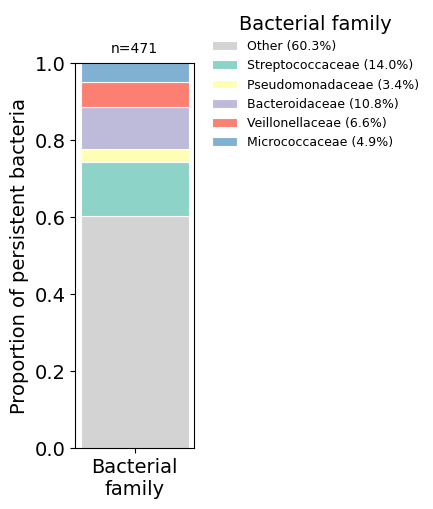

In [20]:
# Keep top host-matching bac_family values in the same order, plus an Other bucket
if 'host_plot_data' not in globals():
    raise ValueError('Run cell 17 first so `host_plot_data` is available.')

# Host-family order and colors from the plot above (excluding aggregated buckets)
host_order = [
    d['group'] for d in host_plot_data
    if d['group'] not in {'Other', 'Unclassified', 'No temperate evidence'}
]
host_palette = sns.color_palette('Set3', n_colors=max(len(host_order), 1))
host_color_map = {fam: host_palette[i] for i, fam in enumerate(host_order)}
host_color_map['Other'] = 'lightgrey'

# Build bacterial family table
bac_persistent_base = (
    bac_persistence
        .filter(pl.col('persistence') >= 0.5)
        .with_columns([
            pl.col('clade_name').str.split('|f__').list[-1].str.split('|g__').list[0].alias('bac_family')
        ])
)

# Keep host-matching families and collapse all non-matching into Other
bac_family_plot_data = (
    bac_persistent_base
        .with_columns(
            pl.when(pl.col('bac_family').is_in(host_order))
              .then(pl.col('bac_family'))
              .otherwise(pl.lit('Other'))
              .alias('group')
        )
        .group_by('group')
        .agg(pl.len().alias('n_viruses'))
        .with_columns(
            pl.col('group').replace_strict(
                ['Other'] + host_order,
                list(range(len(host_order) + 1)),
                default=len(host_order) + 1
            ).alias('order_idx')
        )
        .sort('order_idx')
        .with_columns((pl.col('n_viruses') / pl.col('n_viruses').sum()).alias('proportion'))
        .select(['group', 'n_viruses', 'proportion'])
        .to_dicts()
 )

if len(bac_family_plot_data) == 0:
    raise ValueError('No bac_family values were available after filtering.')

bac_special_colors = {
    row['group']: host_color_map.get(row['group'], 'lightgrey')
    for row in bac_family_plot_data
}

fig, ax = plt.subplots(1, 1, figsize=(2, 5), sharey=True)
stacked_bar(
    ax,
    bac_family_plot_data,
    'Bacterial\nfamily',
    special_colors=bac_special_colors,
    palette_name='Set3'
 )

ax.set_ylabel('Proportion of persistent bacteria')

# Put legend on the far right
fig.subplots_adjust(right=0.72, wspace=0.2)
ax.legend(
    title='Bacterial family',
    bbox_to_anchor=(0.75, 1),
    loc='upper left',
    bbox_transform=fig.transFigure,
    fontsize=9,
    frameon=False
)

plt.show()

In [21]:
phage_host_ratio_lst2 = []

for sample in sylph_tax_df['sample_id'].unique():
    sample_id=sample
    df = sylph_tax_df.filter(pl.col('sample_id') == sample_id)
    virus_df = (
        df
            .filter(pl.col('virus_host').is_not_null())
            .with_columns([
                pl.col('virus_host').str.split(';').list.join('|').alias('cf_virus_host'),
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.replace(r'.*vSPECIES-', '').str.replace(r'\|.*', '').cast(pl.Int64).alias('species_cluster_id'),
            ])
    )
    bac_df = (
        df
            .filter(pl.col('clade_name').str.starts_with('d__Bacteria'))
            .filter(
                (pl.col('clade_name').str.contains(r's__Pseudomonas aeruginosa$')) |
                (pl.col('clade_name').str.contains(r's__Staphylococcus aureus$')) |
                (pl.col('clade_name').str.contains(r's__Haemophilus influenzae$')) |
                (pl.col('clade_name').str.contains(r'g__Achromobacter')) |
                (pl.col('clade_name').str.contains(r'g__Stenotrophomonas')) |
                (pl.col('clade_name').str.contains(r'g__Burkholderia'))
            )
    )
    # join at species level
    match = (
        virus_df
            .join(bac_df[['clade_name', 'taxonomic_abundance']], left_on='cf_virus_host', right_on='clade_name', how='inner')
            .with_columns([
                (pl.col('taxonomic_abundance') / pl.col('taxonomic_abundance_right')).alias('cf_phage_host_ratio'),
                pl.col('clade_name').str.split('t__').list[1].alias('votu_rep'),
            ])
    )
    phage_host_ratio_lst2.append(match)

phage_host_ratio_df2 = (
    pl.concat(phage_host_ratio_lst2)[['sample_id', 'species_cluster_id', 'cf_phage_host_ratio', 'cf_virus_host']]
        .join(merged, on=['species_cluster_id', 'sample_id'], how='inner')
        .join(persistent_base[['species_cluster_id', 'coassembly_group']], on=['species_cluster_id', 'coassembly_group'], how='inner')
)

In [22]:
### Identify longitudinal phage-to-hosts with at least 3 virus-host matches in the dataset
gt_3_pth = (
    phage_host_ratio_df2
    .with_columns([
        pl.col('virus_host').str.split('|g__').list[-1].str.split('|s__').list[0].alias('host_genus')
    ])
    .unique(['host_genus', 'coassembly_group', 'timepoint'])
    .group_by(['host_genus', 'coassembly_group'])
    .len()
    .filter(pl.col('len') > 2)
)

In [23]:
### Remove lipuma samples because they were "enriched"
long_pth_df = (
    phage_host_ratio_df2
        .filter(~pl.col('coassembly_group').str.starts_with('L'))
        .filter(pl.col('cf_phage_host_ratio').is_not_null())
        .with_columns([
            pl.col('virus_host').str.split('|g__').list[-1].str.split('|s__').list[0].alias('host_genus')
        ])
        .join(gt_3_pth[['coassembly_group', 'host_genus']], on=['coassembly_group', 'host_genus'], how='inner')
        .with_columns([
            pl.col('timepoint').min().over('coassembly_group').alias('_min_timepoint'),
        ])
        .with_columns([
            pl.when(pl.col('timepoint').is_not_null())
                .then((pl.col('timepoint') - pl.col('_min_timepoint')).dt.total_days())
                .alias('day_after_min')
        ])
        .drop(['_min_timepoint'])
        [['coassembly_group', 'host_genus', 'species_cluster_id', 'cf_phage_host_ratio', 'day_after_min', 'clinical_status']]
)

In [24]:
long_pth_df.group_by('clinical_status').len()

clinical_status,len
str,u32
"""exacerbation""",37
"""stable""",45
"""Unknown""",9


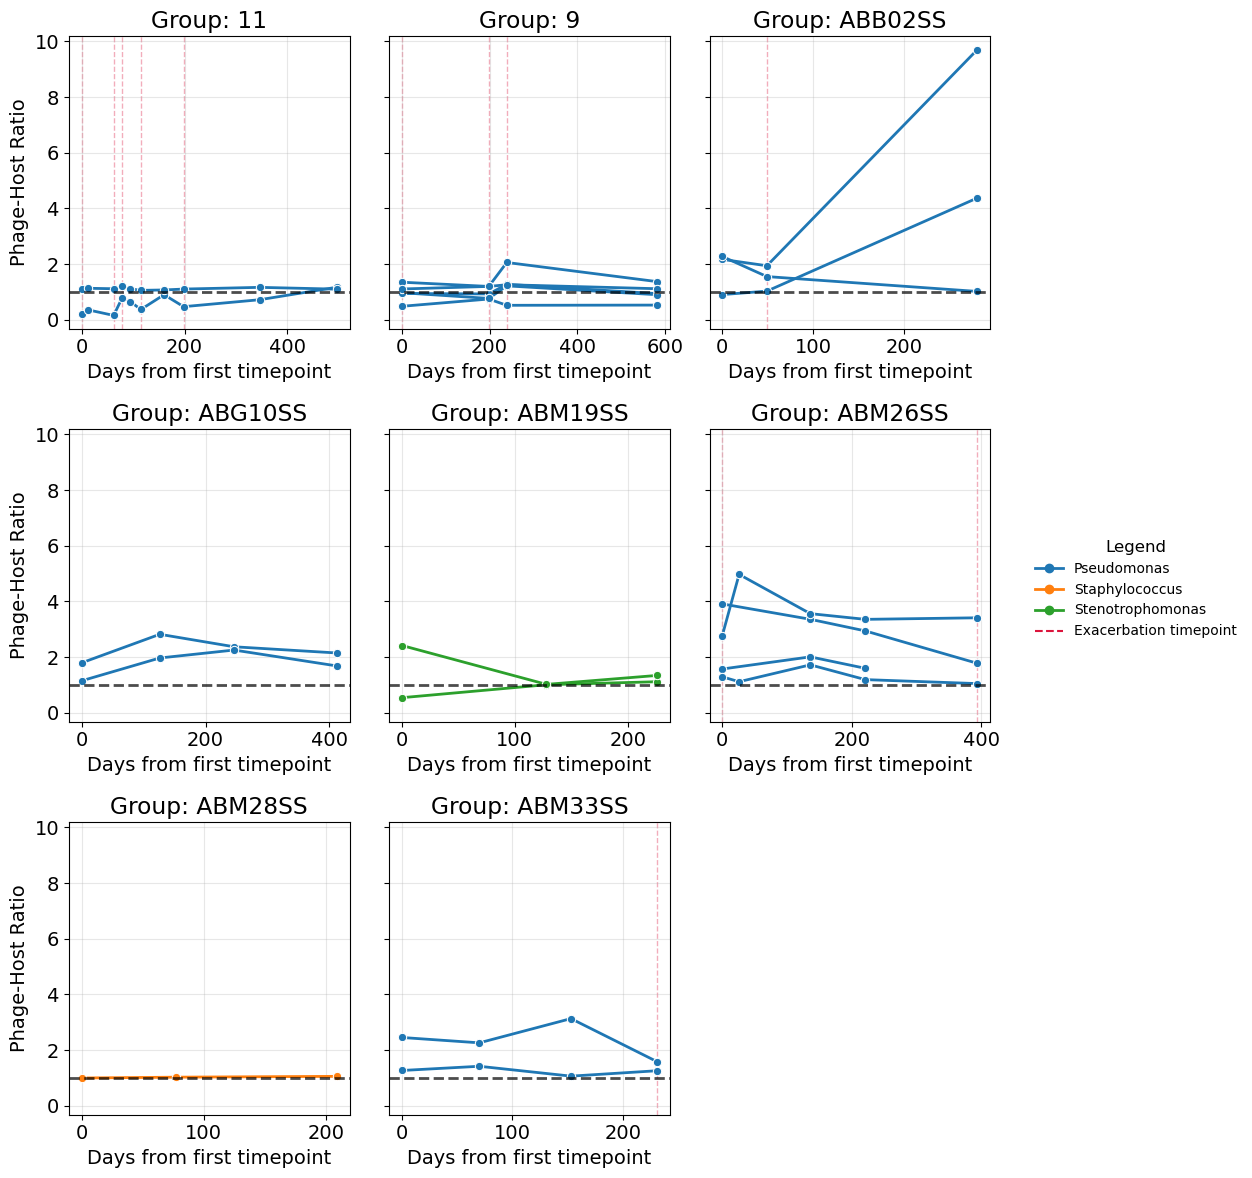

In [25]:
### Lineplot of cf_phage_host_ratio by timepoint, faceted by coassembly_group
from matplotlib.lines import Line2D

# Convert to pandas for better seaborn compatibility
long_pth_df_pd = long_pth_df.to_pandas()

coassembly_groups = sorted(long_pth_df['coassembly_group'].unique())
n_groups = len(coassembly_groups)
n_cols = 3
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), sharey=True)
axes = axes.flatten()

# Get all unique host_genus and create a consistent color palette
all_genera = sorted(long_pth_df['host_genus'].unique())
genus_palette = sns.color_palette('tab10', n_colors=len(all_genera))
genus_colors = dict(zip(all_genera, genus_palette))

for idx, group in enumerate(coassembly_groups):
    ax = axes[idx]
    group_data = long_pth_df_pd[long_pth_df_pd['coassembly_group'] == group]
    
    if len(group_data) == 0:
        ax.text(0.5, 0.5, f'No data for {group}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Coassembly Group: {group}')
        continue
    
    # Highlight exacerbation timepoints
    ex_days = sorted(
        group_data.loc[group_data['clinical_status'] == 'exacerbation', 'day_after_min']
        .dropna()
        .unique()
    )
    for day in ex_days:
        ax.axvline(day, color='crimson', linestyle='--', linewidth=1, alpha=0.35, zorder=0)
    
    sns.lineplot(
        data=group_data,
        x='day_after_min',
        y='cf_phage_host_ratio',
        marker='o',
        markersize=6,
        linewidth=2,
        hue='host_genus',
        style='species_cluster_id',
        palette=genus_colors,
        dashes=False,
        ax=ax,
        legend=False
    )
    
    ax.axhline(1, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_xlabel('Days from first timepoint')
    ax.set_title(f'Group: {group}')
    ax.grid(alpha=0.3)

    if idx % n_cols == 0:
        ax.set_ylabel('Phage-Host Ratio')
    else:
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelleft=False)

# Hide unused subplots
for idx in range(len(coassembly_groups), len(axes)):
    axes[idx].set_visible(False)

# Common legend for host_genus + exacerbation marker
legend_handles = [
    Line2D([0], [0], color=genus_colors[g], lw=2, marker='o', markersize=6, label=g)
    for g in all_genera
]
legend_handles.append(
    Line2D([0], [0], color='crimson', lw=1.5, linestyle='--', label='Exacerbation timepoint')
)
fig.legend(
    handles=legend_handles,
    title='Legend',
    loc='center right',
    bbox_to_anchor=(1.05, 0.5),
    fontsize=10,
    title_fontsize=12,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()

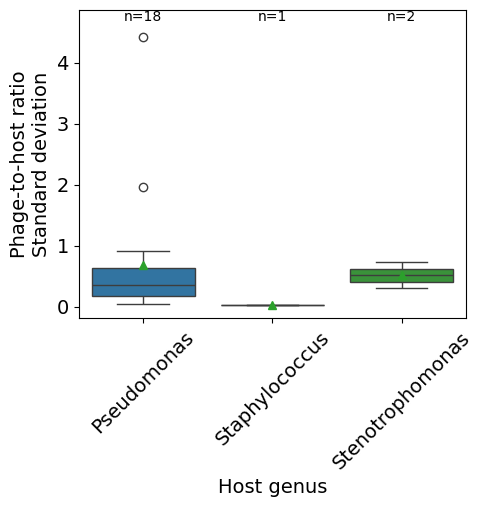

In [26]:
ratio_cv_by_species = (
    long_pth_df
    .filter(pl.col("cf_phage_host_ratio").is_not_null())
    .group_by(["coassembly_group", "species_cluster_id", "host_genus"])
    .agg([
        pl.col("day_after_min").n_unique().alias("n_days"),
        pl.col("cf_phage_host_ratio").count().alias("n_obs"),
        pl.col("cf_phage_host_ratio").mean().alias("cf_phage_host_ratio_mean"),
        pl.col("cf_phage_host_ratio").std().alias("cf_phage_host_ratio_sd"),
    ])
    .with_columns(
        (pl.col("cf_phage_host_ratio_sd") / pl.col("cf_phage_host_ratio_mean")).alias("cf_phage_host_ratio_cv")
    )
)

order = sorted(ratio_cv_by_species["host_genus"].unique().to_list())
counts = (
    ratio_cv_by_species
    .group_by("host_genus")
    .len()
    .sort("host_genus")
)

plt.figure(figsize=[5, 4])
ax = sns.boxplot(
    data=ratio_cv_by_species,
    x="host_genus",
    y="cf_phage_host_ratio_sd",
    order=order,
    hue="host_genus",
    hue_order=order,
    showmeans=True,
    legend=False,
)

y_max = ratio_cv_by_species["cf_phage_host_ratio_sd"].max()
y_pad = 0.05 * y_max if y_max is not None else 0.05

for i, genus in enumerate(order):
    n = counts.filter(pl.col("host_genus") == genus)["len"][0]
    ax.text(i, y_max + y_pad, f"n={n}", ha="center", va="bottom", fontsize=10)

plt.ylabel("Phage-to-host ratio\nStandard deviation")
plt.xlabel("Host genus")
plt.ylim(top=y_max + 2 * y_pad)
plt.xticks(rotation=45)
plt.show()

In [27]:
ratio_cv_by_species['cf_phage_host_ratio_sd'].median()

0.320204992830002

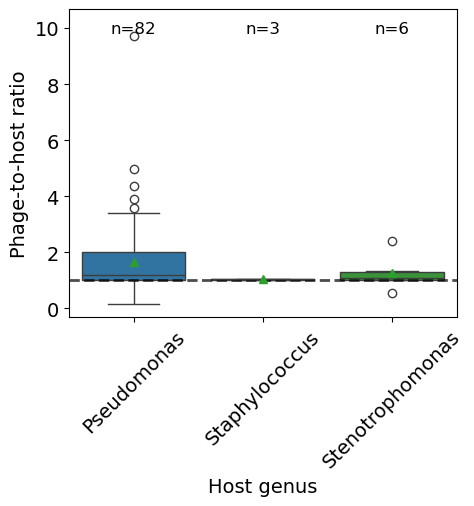

In [28]:
ratio = (
    long_pth_df
    .filter(pl.col("cf_phage_host_ratio").is_not_null())
)

order = sorted(ratio["host_genus"].unique().to_list())
counts = (
    ratio
    .group_by("host_genus")
    .len()
    .sort("host_genus")
)

plt.figure(figsize=[5, 4])
ax = sns.boxplot(
    data=ratio,
    x="host_genus",
    y="cf_phage_host_ratio",
    order=order,
    hue="host_genus",
    hue_order=order,
    showmeans=True,
    showfliers=True,
    legend=False
)

y_max = ratio["cf_phage_host_ratio"].max()
y_pad = 0.05 * y_max if y_max is not None else 0.05

for i, genus in enumerate(order):
    n = counts.filter(pl.col("host_genus") == genus)["len"][0]
    ax.text(i, y_max, f"n={n}", ha="center", va="bottom", fontsize=12)

plt.ylabel("Phage-to-host ratio")
plt.xlabel("Host genus")
plt.ylim(top=y_max + 2 * y_pad)
plt.axhline(y=1, color='black', linestyle='--', linewidth=2, alpha=0.7)
plt.xticks(rotation=45)
plt.show()

In [29]:
ratio['cf_phage_host_ratio'].median()

1.1930627183496922